# Monte Carlo Methods in Python
## Generating random samples from probability distributions

# The beginning ....

During the World War II, a team of scientists, engineers and technicians were furiously working on the first electronic computer - the ENIAC (Electronic Numerical Integrator and Computer), at the University of Pennsylvania in Philadelphia. ENIAC was developed under a 1943 contract with the US Army to speed ballistics calculations. Its physical size was overwhelming—some 18,000 double triode vacuum tubes in a system with 500,000 solder joints. Prof John von Neumann, professor of Mathematics, was interested in developing a preliminary computational model of a thermonuclear reaction for the ENIAC.
![JohnvonNeumann-LosAlamos.gif](attachment:JohnvonNeumann-LosAlamos.gif)

Stan Ulam, also a professor of mathematics, was interested in random processes and when he understood the computing capability of ENIAC, he suggested to John that statistical methods should be studied using ENIAC to solve the thermonuclear reaction problem. John understood the relevance of Ulam's suggestion and proposed the study of a possible statistical approach to solving the problem of neutron diffusion in fissionable material.

The computational algorithm based on random number generated was named 'Monte Carlo' by N Metropolis. The spirit of Monte Carlo is best conveyed by the example discussed in von Neumann’s letter to Robert Richtmyer, the then head of the Theoretical Division of University of Pennsylvania.

Consider a spherical core of fissionable material surrounded by a shell of tamper material. Assume some initial distribution of neutrons in space and in velocity but ignore radiative and hydrodynamic effects. The idea is to now follow the development of a large number of individual neutron chains as a consequence of scattering, absorption, fission, and escape.

At each stage a sequence of decisions has to be made based on statistical probabilities appropriate to the physical and geometric factors. The first two decisions occur at time t = 0, when a neutron is selected to have a certain velocity and a certain spatial position. The next decisions are the position of the first collision and the nature of that collision. If it is determined that a fission occurs, the number of emerging neutrons must be decided upon, and each of these neutrons is eventually followed in the same fashion as the first. If the collision is decreed to be a scattering, appropriate statistics are invoked to determine the new momentum of the neutron. When the neutron crosses a material boundary, the parameters and characteristics of the new medium are taken into account. Thus, a genealogical history of an individual neutron is developed. The process is repeated for other neutrons until a statistically valid picture is generated.

Monte Carlo methods were central to the simulations required for the Manhattan Project, though severely limited by the computational tools at the time. Von Neumann, Nicholas Metropolis and others programmed the ENIAC computer to perform the first fully automated Monte Carlo calculations, of a fission weapon core, in the spring of 1948.


![CNX_Chem_21_04_ChnReact1.jpeg](attachment:CNX_Chem_21_04_ChnReact1.jpeg)
(Credits: LibreTexts Chemistry)

# Random Numbers

Consider a perfectly balanced spinner, spinning on a vertical axis inside a round box, rather like an unmagnetized compass needle. Suppose that the circumference of the box is marked with a scale from 0 to 1, so that when the spinner stops it will point to a value between 0 and 1. Imagine repeatedly spinning the spinner and recording the values when the spinner comes to rest. Under ideal conditions, this experiment will generate a sequence of independent, uniformly distributed random variables.

# Pseudo-Random Number Generators (PRNG)

Using a deterministic algorithm, random numbers are generated (since they are generated using a determinisitc algorithm where if you know the seed, you can reproduce the entire list of random number, therefore, these random numbers are referred to as pseudo-random numbers).

- Most important the numbers should be uniformly distributed between 0 and 1. If we make a histogram, it should appear nearly flat (i.e uniform).
- Successive values should be independent.

The pseudo-random number generators are always vigorously tested to prove randomness. This is because they are  not produced by truly random processes, but rather by deterministic algorithms. A good random number generator will produce a sequence of numbers that is indistinguishable from a sequence of independent uniform random variables.

Thus, fundamentally, the random number generator algorithm generates random integers which are then normalized to give a floating point number from the standard uniform distribution. Random numbers from other distributions are in turn generated using these uniform random deviates, either via general (inverse transform, accept/reject, mixture representations) or specialized adhoc (e.g. Box-Muller) methods.


## Uniform standard random number generator

Most random number generators work by iterating a function $\phi$. The function maps the set of integers $0, 1, . . . , m - 1$ onto itself, so that starting from some initial value $z_0$ called the seed, the successive values are given by
# $ z_{i+1} = \phi(z_i)$

Note: In a system of arithmetic for integers (modular arithmetic), numbers wrap around after reaching a certain value called the modulus (or the period). Here m refers to this modulus.

Numbers in the range $0$ to $1$ are then formed by calculating $z_i/m$. The idea is to find a function that produces a highly chaotic sequence, so that the numbers $z$, skip about in the range $0, 1 . . .m - 1$ with no obvious pattern. Obviously if the sequence returns to a value it has visited before, the sequence will repeat. For this reason the function is chosen so that every one of the values in $0,1...N- 1$ is visited in a cycle and $m$ is chosen to be large, say $2^{32}$, to maximise the time between repetition (i.e repetition of the sequence).

An example of such a function is the **multiplicative congruential generator**

**Linear congruential generators (LCG)**

# $ z_{i + 1} = (a \, z_i + c) \, mod \, m$  ==> returns reminder after dividing (a z_i + c) by m
**where $z$ is the sequence of pseudo-random numbers**

## $m$ is $> 0$ the period

## $a$ can lie between (0,m) is the multiplier

## $c$ can lie between (0,m) is the increment

## $z_0$ - the initial value of sequence is known as the seed.

The seed can be specified by the user, which enables the sequence to be reproduced; a facility that is helpful in debugging computer programs. Alternatively, the seed can be calculated as a function of the internal state of the computer, for example the current time.

The values of $m$, $a$, $c$ and $z_0$ should be chosen such as to get a period almost equal to $m$.

According to Hull-Dobell Theorem: The LCG will have a full period (the PRNG traverses every valid state before returning to the seed state) for all seeds if and only if

* $c$ and $m$ are relatively prime,
* $a−1$ is divisible by all prime factors of $m$,
* $a−1$ is a multiple of $4$ and if $m$ is a multiple of $4$.

## The LCG is typically coded to return $z/m$, a floating point number in (0, 1). Obviously, this can be easily scaled to any other range $(a,\, b)$.


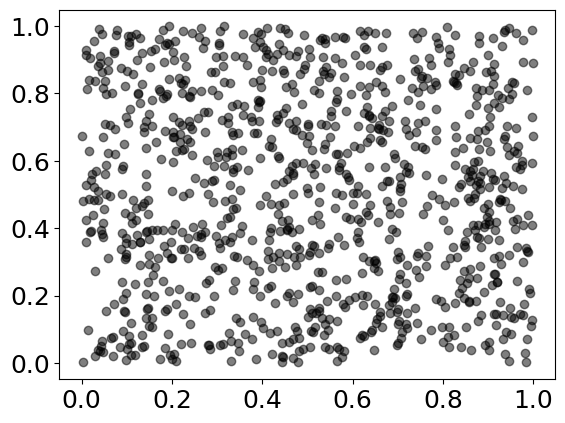

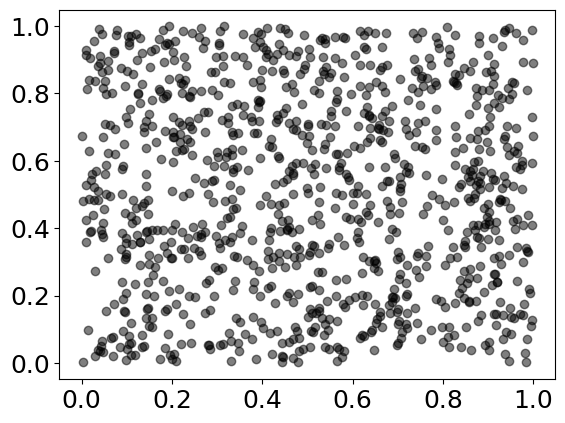

In [ ]:
def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a*rng.current + c) % m  #Estimating the remainder of the division ( x mod y).
    return rng.current/m

# setting the seed # Here defined as a global variable
rng.current = 2

import matplotlib.pyplot as plt
import time
from IPython import display
for i in range(1000):
    plt.plot(rng(),rng(),'ko',alpha=0.5)
    display.clear_output(wait=True)
    display.display(plt.gcf())
    time.sleep(.01)
    plt.tick_params(labelsize=15)
    plt.tick_params(axis='x', labelsize=18)
    plt.tick_params(axis='y', labelsize=18)


# Numpy random generator
**numpy.random.default_rng()**
Numpy’s random number routines produce pseudo random numbers using combinations of a BitGenerator to create sequences and a Generator to use those sequences to sample from different statistical distributions:
The default BitGenerator used by Generator is **PCG64**. PCG-64 is a 128-bit implementation of O’Neill’s permutation congruential generator.
### PCG-64 has a period of $2^{128}$ and supports advancing an arbitrary number of steps (jump ahead) as well as $2^{127}$ streams.

In jump-ahead, parallelism is achieved by splitting a single pseudorandom sequence into disjoint index ranges, whereas in multiple-stream methods like PCG-64, parallelism is achieved by assigning different increment parameters to generate independent sequences from the same seed.



## Monte Carlo RNG design: a minimal working example
#### Physical problem (toy version) - Nuclear Fission Problem

- 10 Uranium nuclei + some number of neutrons

- Each nucleus undergoes independent fission

- For each fission, we randomly sample:

 * Neutron velocity

 * Nuclear state (ground / excited)

In [ ]:
## Step 1: A simple LCG with jump-ahead

class LCG:
    def __init__(self, seed, a=1103515245, c=12345, m=2**32):
        self.a = a
        self.c = c
        self.m = m
        self.state = seed

    def random(self):
        self.state = (self.a * self.state + self.c) % self.m
        return self.state / self.m

    def jump_ahead(self, n):
        # Simple (inefficient) jump for demonstration
        for _ in range(n):
            self.random()
## Step 2: Parallelisation across 10 cores (sequence splitting)

## Each “core” gets a disjoint block of the same RNG sequence.

NUM_CORES = 10
BLOCK_SIZE = 100
BASE_SEED = 42
## Step 3: Multiple streams inside each core

## Within each core:

## One stream → neutron velocity

## One stream → nuclear state

## We model this by different increments.

def make_stream(seed, increment):
    return LCG(seed=seed, c=increment)
## Step 4: One core simulating one Uranium nucleus
def simulate_fission(core_id):
    # Jump-ahead for parallelism
    base_rng = LCG(seed=BASE_SEED)
    base_rng.jump_ahead(core_id * BLOCK_SIZE)

    # Multiple streams inside this core
    neutron_rng = make_stream(base_rng.state, increment=12345 + 2*core_id)
    state_rng   = make_stream(base_rng.state, increment=54321 + 2*core_id)

    # Monte Carlo sampling
    neutron_velocity = neutron_rng.random() * 2.0   # arbitrary units
    uranium_state = "excited" if state_rng.random() > 0.7 else "ground"

    return neutron_velocity, uranium_state
## Step 4: One core simulating one Uranium nucleus
def simulate_fission(core_id):
    # Jump-ahead for parallelism
    base_rng = LCG(seed=BASE_SEED)
    base_rng.jump_ahead(core_id * BLOCK_SIZE)

    # Multiple streams inside this core
    neutron_rng = make_stream(base_rng.state, increment=12345 + 2*core_id)
    state_rng   = make_stream(base_rng.state, increment=54321 + 2*core_id)

    # Monte Carlo sampling
    neutron_velocity = neutron_rng.random() * 2.0   # arbitrary units
    uranium_state = "excited" if state_rng.random() > 0.7 else "ground"

    return neutron_velocity, uranium_state
## Step 5: Run the simulation (conceptually parallel)
results = []
for core in range(NUM_CORES):
    results.append(simulate_fission(core))

for i, res in enumerate(results):
    print(f"Uranium {i}: velocity={res[0]:.3f}, state={res[1]}")


In [ ]:
## Step 2: Parallelisation across 10 cores (sequence splitting)

## Each “core” gets a disjoint block of the same RNG sequence.

NUM_CORES = 10
BLOCK_SIZE = 100
BASE_SEED = 42


In [ ]:
## Step 3: Multiple streams inside each core

## Within each core:

## One stream → neutron velocity

## One stream → nuclear state

## We model this by different increments.

def make_stream(seed, increment):
    return LCG(seed=seed, c=increment)


In [ ]:
## Step 4: One core simulating one Uranium nucleus
def simulate_fission(core_id):
    # Jump-ahead for parallelism
    base_rng = LCG(seed=BASE_SEED)
    base_rng.jump_ahead(core_id * BLOCK_SIZE)

    # Multiple streams inside this core
    neutron_rng = make_stream(base_rng.state, increment=12345 + 2*core_id)
    state_rng   = make_stream(base_rng.state, increment=54321 + 2*core_id)

    # Monte Carlo sampling
    neutron_velocity = neutron_rng.random() * 2.0   # arbitrary units
    uranium_state = "excited" if state_rng.random() > 0.7 else "ground"

    return neutron_velocity, uranium_state


In [ ]:
## Step 5: Run the simulation (conceptually parallel)
results = []
for core in range(NUM_CORES):
    results.append(simulate_fission(core))

for i, res in enumerate(results):
    print(f"Uranium {i}: velocity={res[0]:.3f}, state={res[1]}")


Uranium 0: velocity=1.582, state=excited
Uranium 1: velocity=1.896, state=excited
Uranium 2: velocity=0.416, state=ground
Uranium 3: velocity=1.346, state=ground
Uranium 4: velocity=0.202, state=ground
Uranium 5: velocity=0.823, state=ground
Uranium 6: velocity=0.256, state=ground
Uranium 7: velocity=1.523, state=excited
Uranium 8: velocity=0.252, state=ground
Uranium 9: velocity=1.191, state=ground


#### Block splitting → ensures different cores simulate independent neutron–uranium histories.

#### Streams → ensure different stochastic variables within a history are sampled in a structured and statistically clean way.

### Scaling a random numbers generated between 0 to 1 to any uniform distribution

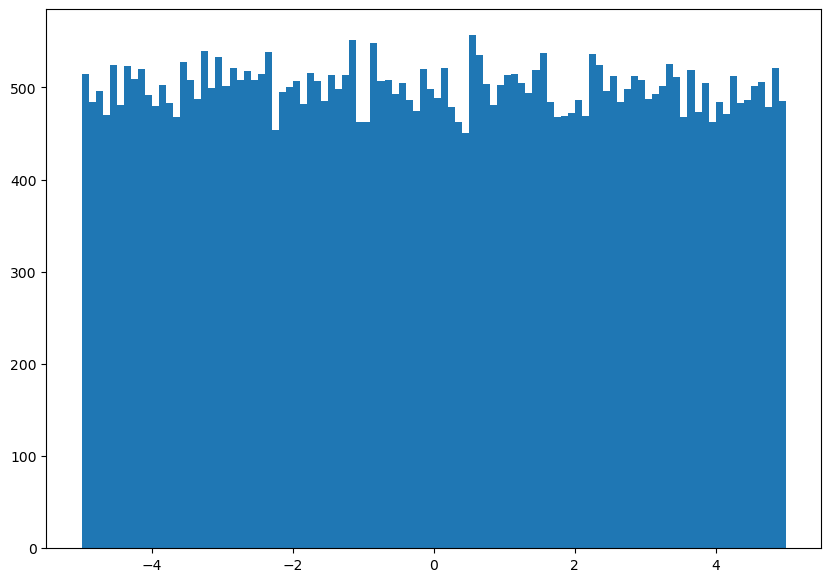

In [ ]:
### Scaling a random numbers generated between 0 to 1 to any uniform
#Give the minimum value of the uniform distribution
min = -5
#Give the maximum value of the uniform distribution
max = 5

u = np.random.random(50000)

X = min + u*(max-min)


plt.figure(figsize=(10,7))
plt.hist(X,bins=100)
plt.show()


# Different Methods of Sampling Technique
# 1. Inverse Transform Method (also known as inverse CDF sampling technique)
The inverse transform sampling is a method for generating sample numbers at random from any probability distribution given its cumulative distribution function.
Any random variable can be simulated by transforming a computer generated uniform random variable.

# The inverse transform sampling method works as follows:

## * Generate a random number $u$ from the standard uniform distribution in the interval $[0,1]$, e.g. from ${\displaystyle U\sim \mathrm {Unif} [0,1].}$

## * Find the inverse of the desired CDF, e.g. ${\displaystyle F_{X}^{-1}(x)}$.

## * Compute ${\displaystyle X=F_{X}^{-1}(u)}$. The computed random variable $X$ has distribution $F_X(x)$.


## The simplest example is the standard exponential random variable, with probability density $e^{-x}$, $x > 0$.

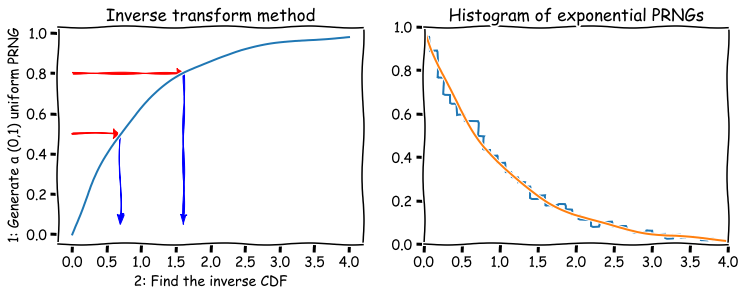

In [ ]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
def expon_pdf(x, lmabd=1):
    """PDF of exponential distribution."""
    return lmabd*np.exp(-lmabd*x)

# The cumulative distribution function is obtained by integrating the probability distribution from -infinity to x.
# Here in the example of exponential distribution function the range of possible x is zero to infinity.

def expon_cdf(x, lambd=1):
    """CDF of exponetial distribution."""
    return 1 - np.exp(-lambd*x)

# Inverse of the cumulative distribution function is also referred to as the quantile function

def expon_icdf(p, lambd=1):
    """Inverse CDF of exponential distribution - i.e. quantile function."""
    return -np.log(1-p)/lambd


dist = stats.expon()
x = np.linspace(0,4,100)
y = np.linspace(0,1,100)

#plt.xkcd() ----> Sketch - Style plotting technique available in matplotlib: (https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xkcd.html)

with plt.xkcd():
    plt.figure(figsize=(12,4))
    plt.subplot(121)
    plt.plot(x, expon_cdf(x))
    plt.xlabel('X')

    for q in [0.5, 0.8]:
        plt.arrow(0, q, expon_icdf(q)-0.1, 0, head_width=0.05, head_length=0.1, fc='r', ec='r')
        plt.arrow(expon_icdf(q), q, 0, -q+0.1, head_width=0.1, head_length=0.05, fc='b', ec='b')
    plt.ylabel('1: Generate a (0,1) uniform PRNG')
    plt.xlabel('2: Find the inverse CDF')
    plt.title('Inverse transform method');

    plt.subplot(122)
    u = np.random.random(10000)
    v = expon_icdf(u)
    plt.hist(v, histtype='step', bins=100, density=True, linewidth=2)
    plt.plot(x, expon_pdf(x), linewidth=2)
    plt.axis([0,4,0,1])
    plt.title('Histogram of exponential PRNGs');



### Scaling a Standard Normal Distribution to any normal distribution
The normal distribution can also be simulated in a straightforward manner. First note that, if $Z$ has distribution $N(0,1)$ then $\mu + \sigma Z$ distribution $N(\mu,\sigma^2)$. The problem of sampling from $N(\mu,\sigma^2)$ is therefore reduced to that of sampling from $N(0,1)$ and then taking a simple linear transformation.

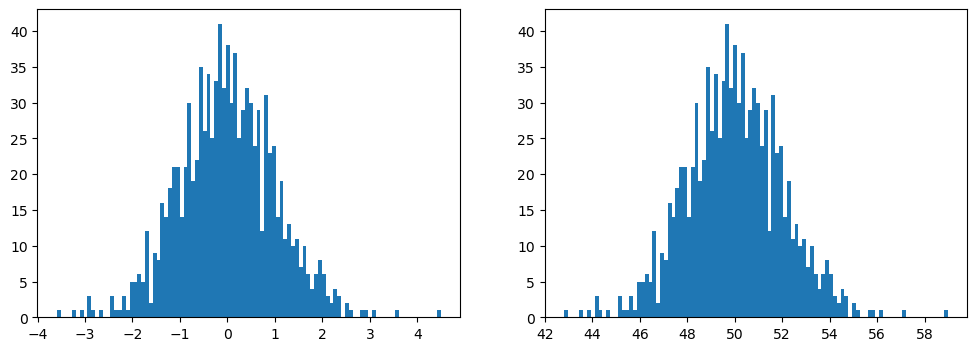

In [ ]:
from numpy.random import default_rng
rng = default_rng()
vals = rng.standard_normal(1000)

mu = 50
sigma = 2

Z_dist = mu + vals*sigma

plt.figure(figsize=(12,4))
plt.subplot(121)
plt.hist(vals,bins=100)


plt.subplot(122)
plt.hist(Z_dist,bins=100)
plt.show()

# Creating a random number from an unknown/ arbitrary distribution

### Suppose we have a random sample whose population distribution is unknown to us.
Even in such a case, it is possible to generate random numbers from the unknown distribution using the inverse CDF sampling method, however, using interpolation technique.



## Interpolation
Interpolation is a numerical analysis technique wherein with the given set of discrete data set of values of the dependent and independent variables, one can generate new values of dependent variable for the intermediate values of the independent variable.

* The simplest way one can interpolate is by simply joining the given dataset values by a straight line known as linear interpolation.

* Linear interpolation results in discontinuities at each point. Often a smoother interpolating function is desirable, such as cubic interpolation. Cubic interpolation is the simplest method that offers true continuity between the segments.

(Credits: Interpolation Methods by Paul Bourke, December 1999) (More reading: https://docs.scipy.org/doc/scipy/tutorial/interpolate.html)

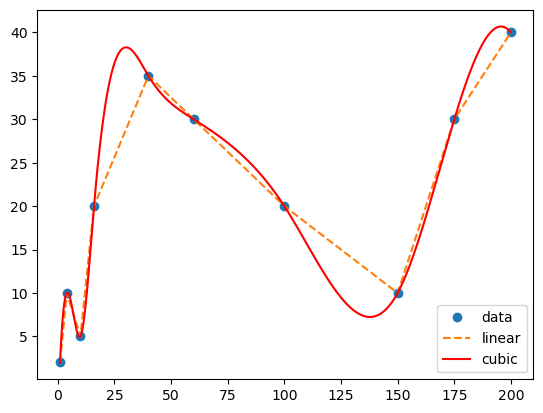

In [ ]:
# Demonstration of how interpolation works
import matplotlib.pyplot as plt
import numpy as np
from scipy import interpolate
x = [1,4,10,16,40,60,100,150,175,200]
y = [2,10,5,20,35,30,20,10,30,40]
f1 = interpolate.interp1d(x, y)
f2 = interpolate.CubicSpline(x, y)

xnew = np.arange(1, 200, 0.1)
ynew1 = f1(xnew)   # use interpolation function returned by `interp1d`
ynew2 = f2(xnew)   # use interpolation function returned by 'CubicSpline'
plt.plot(x, y, 'o',xnew,ynew1,'--',xnew,ynew2,'r-')
plt.legend(['data', 'linear', 'cubic'], loc='best')

plt.show()

[-inf   1.   3.   3.   4.] [0.   0.25 0.5  0.75 1.  ]


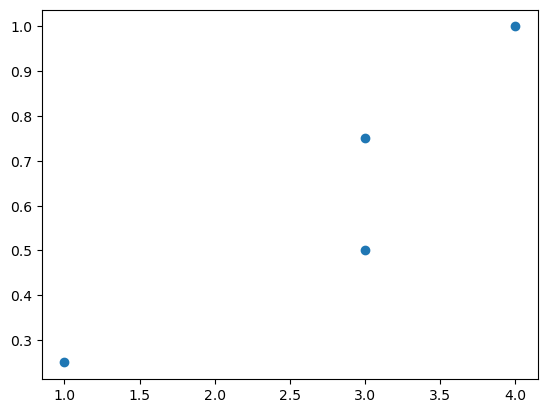

In [ ]:
from statsmodels.distributions.empirical_distribution import ECDF
ecdf = ECDF([3, 3, 1, 4])
#help(ecdf)
print(ecdf.x,ecdf.y)
plt.plot(ecdf.x,ecdf.y,'o')
plt.show()

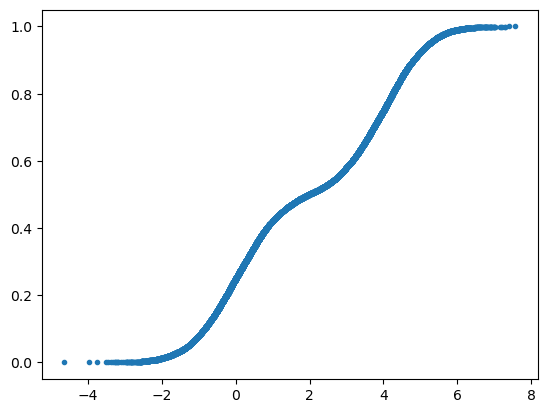

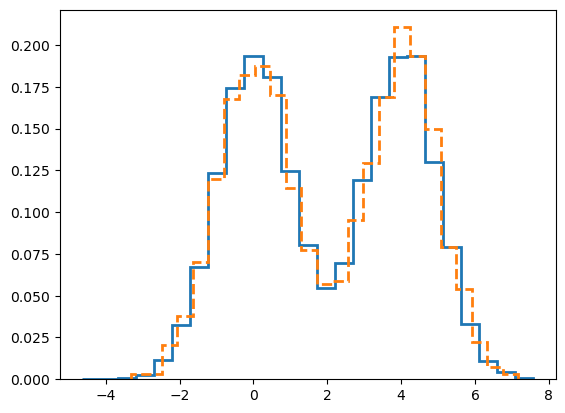

In [ ]:
import numpy as np
from statsmodels.distributions.empirical_distribution import ECDF
# Make up some random data
# Creating a random sample of not a pure normal distribution
x = np.concatenate([np.random.normal(0, 1, 10000), np.random.normal(4, 1, 10000)])

#Generate the empirical cumulative distribution
ecdf = ECDF(x)
plt.plot(ecdf.x,ecdf.y,'.')
plt.show()

#This gives the inverse of CDF function, also called quantile function.
f=interpolate.interp1d(ecdf.y, ecdf.x, assume_sorted=True,fill_value='extrapolate')

r = np.random.random(5000)

ys = np.array(f(r))

plt.hist(x, 25, histtype='step', density=True, linewidth=2)

plt.hist(ys, 25, histtype='step', density=True, linewidth=2, linestyle='--');


# Rejection sampling (Accept- reject method)

Rejection Sampling is a Monte Carlo algorithm for sampling from sophisticated distributions.
This complicated distribution is referred to as the target distribution.
For example see the below distribution function, $f(x)$.

Inorder to sample this target distribution we use another distribution which is easier for us to sample e.g uniform or gaussian distribution, it is referred to as the proposal distribution $g(x)$.
For the below case, let us consider a uniform distribution and scale it such a way that it encompasses the entire target distribution. Each value of the random variable in the uniform distribution has equal probability. Now let us sample the first value of the random variable, say $x'$. According to the uniform distribution it has $g(x')$ probability of occurence, however, the target distribution has only a probability of $f(x')$. Now, $ y = g(x')/f(x') \le C$ where $C$ is the maximum possible ratio.

Now, we want to decide if the randomly sampled $x'$ should be accepted or rejected. How do we do that?
For the given $x'$, comparing the target and the proposal distribution functions, the possible values of densities can vary between $0$ and $C(g(x'))$. What could be the possible density of the randomly sampled x' value?

This is decided by randomly sampling a uniform distribution of $y$ between 0 and $C(g(x'))$. If the randomly sampled density value is greater than $f(x')$ it is rejected and if it is less than $f(x')$ it is accepted.

Since the acceptance and rejection of a randomly sampled $x'$ is based on a Monte Carlo sampling. This is considered as one of the Monte Carlo sampling algorithm.

In the below example, the region of rejection is much larger than the region of acceptance. Therefore, there is a lot of wastage of the power of computation. This can be reduced by choosing an appropriate proposal distribution. Here in the below case, it can be a Gaussian.  



[1 0 1 ... 0 0 1]


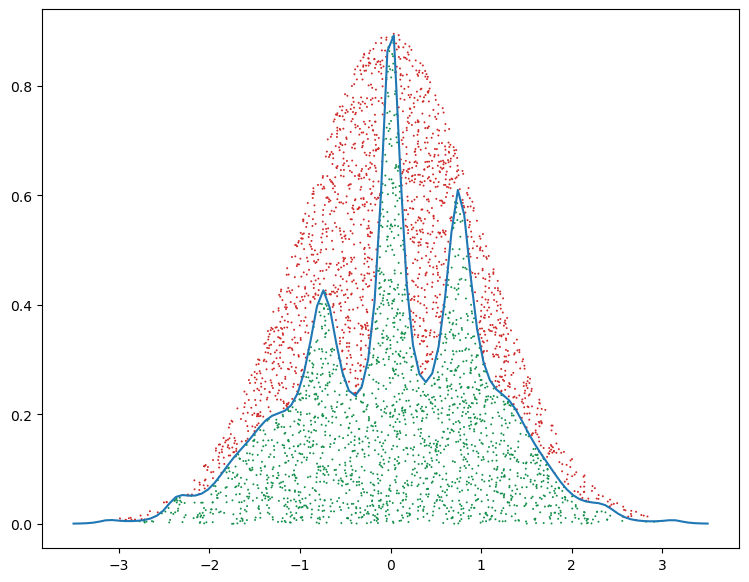

Efficiency for uniform proposal distribution is 20.3%
Efficiency for normal proposal distribution is 53.8%


In [ ]:
from scipy import stats
import numpy as np
x = np.linspace(-3.5,3.5,100)
#Target Distribution
def target(x):
    import numpy as np
    return np.array((np.exp((x**2)/2) *(((np.sin(x+6))**2) + 3* ((np.cos(x))**2) * ((np.sin(4*x))**2) +1))**-1)


# Gaussian proposed distribution
dist = stats.norm()

def batch_sample_1(function, num_samples, xmin=-3, xmax=3, ymax=1):
    x = np.random.uniform(low=xmin, high=xmax, size=num_samples)
    y = np.random.uniform(low=0, high=ymax, size=num_samples)
    passed = (y < function(x)).astype(int) # if passed 1 else it is 0
    return x, y, passed

X, Y, passed_uniform = batch_sample_1(target, 10000)


def batch_sample_2(function, num_samples, xmin=-3, xmax=3, ymax=1,scale=2.25):
    x = np.random.uniform(low=xmin, high=xmax, size=num_samples)
    y = np.random.uniform(low=0, high=ymax, size=num_samples)
    x_=[]
    y_=[]
    passed_=[]
    for i in range(len(y)):
        if y[i] < scale*dist.pdf(x[i]):
            passed_.append((y[i] < function(x[i])).astype(int))
            y_.append(y[i])
            x_.append(x[i])
    return x_, y_, passed_


X_, Y_, passed_norm = batch_sample_2(target, 10000)
#print(passed_norm)

print(passed_uniform)
#Illustration
plt.figure(figsize=(9,7))
plt.plot(x,target(x))
plt.scatter(X, Y, c=passed_uniform, cmap="RdYlGn", vmin=-0.1, vmax=1.1, lw=0, s=2)
#The function of cmap="RdYlGn" maps a number between 0 and 1 to a corresponding color, where 0 gets mapped to red, 0.5 to yellow and 1 to green.
plt.scatter(X_, Y_, c=passed_norm, cmap="RdYlGn", vmin=-0.1, vmax=1.1, lw=0, s=2)
#plt.plot(x,uniform(x,-3,3,0.9))
#plt.plot(x,scale*dist.pdf(x),'r')
plt.show()



print(f"Efficiency for uniform proposal distribution is {np.mean(passed_uniform) * 100:0.1f}%")
print(f"Efficiency for normal proposal distribution is {np.mean(passed_norm) * 100:0.1f}%")

In [ ]:
#Example of Monte Carlo integration to calculate the area under the curve
xlow = -3
xhigh = 3
ylow = 0
yhigh = 1
#dz=1

Area = (xhigh-xlow)*(yhigh-ylow)
print(Area *np.mean(passed_uniform))

import scipy.integrate as integrate
expr = integrate.quad(lambda x: target(x), -3, 3)
print(expr)

1.1934
(1.2158908795358705, 1.1713172796286944e-08)


# Box-Muller method


The Box–Muller transform developed by two mathematicians George Edward Pelham Box and Mervin Edgar Muller, is a random number sampling method for generating pairs of independent, standard, normally distributed (zero expectation, unit variance) random numbers, given a source of uniformly distributed random numbers.

![Screenshot%202023-09-12%20at%202.18.23%20PM.png](attachment:Screenshot%202023-09-12%20at%202.18.23%20PM.png)

## Methodology

* The Box - Muller transform starts with 2 random uniform numbers $u$ and $v$.
* Generate an exponentially distributed variable $r^2$ from $u$ using the inverse transform method. That is $r^2$ is exponentially distributed between 0 and infinity.
* Generate a variable $\theta$ uniformly distributed on $(0,2\pi)$ from $v$ by scaling.
* In polar co-ordinates, the vector $(r,\theta)$ has an independent bivariate normal distribution
* Hence, the projection onto the x and y axes give independent univariate normal random numbers





/Users/shabnam/miniconda3/envs/threeML/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


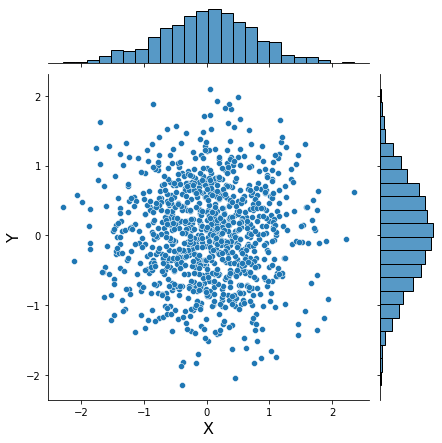

In [ ]:
import seaborn as sns
import numpy as np
n = 1000
u1 = np.random.random(n) # Generating random values from a uniform distribution between 0 and 1.
u2 = np.random.random(n)
#Generating r^2 using the inverse transform method
r_squared = -np.log(u1) #quantile function of exponential distribution
r = np.sqrt(r_squared)
#plt.hist(r_squared,bins=100)
theta = 2*np.pi*u2
#Projections of the vector (r, theta) on to the x and y axes
x = r*np.cos(theta)
y = r*np.sin(theta)

ax=sns.jointplot(x, y, kind='scatter');
ax.set_axis_labels('X', 'Y', fontsize=16)


In [ ]:
# v=[]
# for i in range(10):
#     v.append(np.random.randint(0,high=2))

# print(v)

In [ ]:
# np.random.randint(2, size=10)

In [ ]:
# np.random.randint(0,high=2)


# Estimating the probability of getting a head while a coin toss using Monte Carlo method

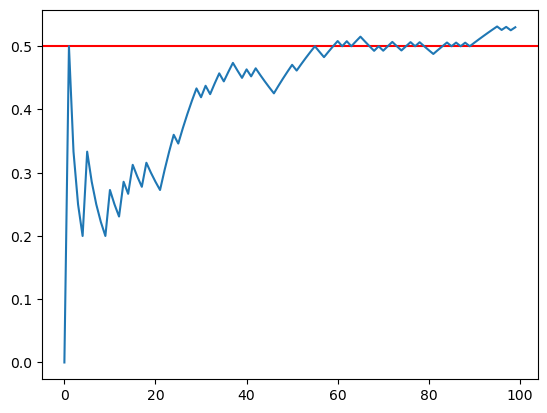

In [ ]:
#randint() --> Return random integers from low (inclusive) to high (exclusive).
def coin_flip():
    return np.random.randint(0,high=2)
n=100
ht=[]
prob=[]
flip = coin_flip()
for i in range(n):
    ht.append(coin_flip())  #np.random.randint(0,high=2)
    #print(ht)
    prob.append(np.mean(ht))

plt.figure()
plt.axhline(y=0.5,color='r')
plt.plot(range(n),prob)

plt.show()


In [ ]:
# coin_flip()

# Monte Carlo Integration

Suppose we want to find the value of

## $\int_{a}^{b} f(x) dx$

The basic idea of Monte Carlo Integration is simple. It estimates the integral by estimating the fraction of random points that fall below f(x) multiplied by the area A or volume, V.


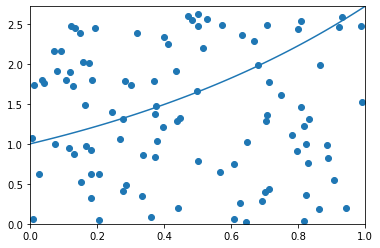

In [ ]:
x = np.linspace(0, 1, 100)
plt.plot(x, np.exp(x));
pts = np.random.uniform(0,1,(100, 2))
pts[:, 1] *= np.e  # equivalent x = x*np.e
plt.scatter(pts[:, 0], pts[:, 1])
plt.xlim([0,1])
plt.ylim([0, np.e]);

In [ ]:
# Check analytic solution
from sympy import symbols, integrate, exp
x = symbols('x')
expr = integrate(exp(x), (x,0,1))
expr.evalf()

1.71828182845905

In [ ]:
#Cross checked with scipy integrate module
from scipy import integrate
integrate.quad(exp, 0, 1)

(1.7182818284590453, 1.9076760487502457e-14)

In [ ]:
# With what size of the random number does, the value approach the numerical value.
# Monte Carlo approximation
sol_=[]
for n in 10**np.array([1,2,3,4,5,6,7,8]):
    pts = np.random.uniform(0, 1, (n, 2))
    pts[:, 1] *= np.e
    count = np.sum(pts[:, 1] < np.exp(pts[:, 0])) #The comparison pts[:, 1] < np.exp(pts[:, 0]) creates a boolean array (True for points below the curve, False otherwise).
    #np.sum(pts[:, 1] < np.exp(pts[:, 0])) counts how many True values exist.
    area = np.e * 1 # area of region
    sol = area * (count)/n
    print('%10d %.6f' % (n, sol))
    sol_.append(sol)



        10 1.902797
       100 1.848432
      1000 1.698926
     10000 1.735079
    100000 1.719803
   1000000 1.719794
  10000000 1.717912
 100000000 1.718139


In [ ]:
# print(np.sum(pts[:, 1] < np.exp(pts[:, 0])))
# pts[:, 1] < np.exp(pts[:, 0])

In [ ]:
def f(x):
    return x * np.cos(71*x) + np.sin(13*x)

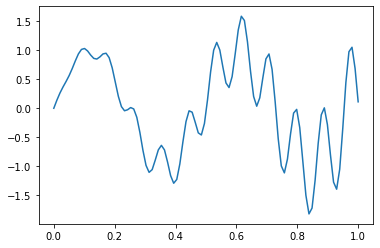

In [ ]:
x = np.linspace(0, 1, 100)
plt.plot(x, f(x));

In [ ]:
from sympy import sin, cos, symbols, integrate
x = symbols('x')
val=integrate(x * cos(71*x) + sin(13*x), (x, 0,1)).evalf()
print(val)

0.0202549391023941


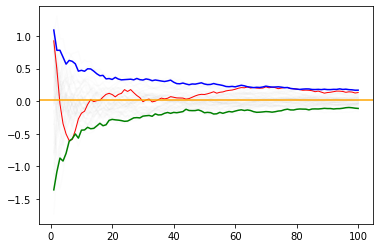

In [ ]:
n = 100
reps = 50
#Generating the random numbers for the 50 random variable X with size 100
fx = f(np.random.random((n, reps)))  #n--> rows; reps--> columns
#Here using a more simplistic approach to integration in a numerical form is done.
# Here the cumulative sum weighted by the number of samples is considered as an approximation to the integral assuming the width = unity.
#np.cumsum(x, axis=0) --> sum over rows for each of the reps columns
#b-a/np.arange(1, n+1) --> Delta x, where b and a are the upper and lower limit of integration. Here in the above case the x limits are 0 and 1, see the above plot.
y =  1/np.arange(1, n+1)[:, None] *np.cumsum(fx, axis=0) ## # sum over rows for each of the reps columns

lower, upper = np.percentile(y, [2.5, 97.5], axis=1)

plt.plot(np.arange(1, n+1), y, c='grey', alpha=0.02)
plt.plot(np.arange(1, n+1), y[:, 5], c='red', linewidth=1);
plt.plot(np.arange(1, n+1), upper, 'b', np.arange(1, n+1), lower, 'g');

plt.axhline(y=val, color='orange')


In [ ]:
#np.random.random((n, reps))

In [ ]:
#print(1/np.arange(1, n+1)[:, None])
#print(len(y))

In [ ]:
#len(np.cumsum(x, axis=0))

In [ ]:
a = np.array([[1,2,3], [4,5,6],[3,6,7]])
print(a)

[[1 2 3]
 [4 5 6]
 [3 6 7]]


In [ ]:
print(np.cumsum(a,axis=0))

[[ 1  2  3]
 [ 5  7  9]
 [ 8 13 16]]


In [ ]:
# x=np.random.random((n, reps))[:,0]
# plt.figure()
# plt.plot(x,f(x),'b-')
# plt.figure()
# plt.plot(np.arange(1, n+1), 1/np.arange(1, n+1)*np.cumsum(f(x)),'r-')


In [ ]:
# # if one increases the number of sampling (is equivalent to increase of number of experiments)
# sample_mean=[]
# for i in range(reps):
#     sample_mean.append(np.mean(y[:,i]))

# plt.hist(sample_mean,bins=50)
# plt.axvline(x=0.0202549,color='red')
# print(np.mean(sample_mean))
# print('The standard deviation of the integral is',np.std(sample_mean)*(reps)**0.5)

In [ ]:
#1/np.arange(1, n+1)[:, None]#*

In [ ]:
#np.cumsum(x[0], axis=0)

In [ ]:
#print(len(y))

# Using Bootstrap

Bootstrapping is a method of random sampling with replacement from a given sample data. It allows you to make an inference about the population from a given sample data.
From a single sample dataset say of N observations, let us say we want to find estimate the mean of the population. However, currently with a given sample, I have only the estimate of the mean of N observations. Now, using the bootstrap resampling method, we sample the given observational dataset of N and create another sample dataset of N observations itself. Here, we note we allow for replacement. This mean, for eg. the original sample ==> [0,1,2,4] now a bootsrapped sample can look like [0,0,1,2] or [1,2,4,4] etc, thus, from these each bootstrapped sample, one can estimate say the mean (bootstrap estimate) and then make a histogram of these means and the average of that distribution will correspond to the population mean and also estimate the variance.

In [ ]:
import numpy as np

x = np.array([2, 4, 7, 10, 12])
n = len(x)
reps = 10000

boot_means = np.zeros(reps)

for i in range(reps):
    sample = np.random.choice(x, size=n, replace=True)
    boot_means[i] = np.mean(sample)

lower, upper = np.percentile(boot_means, [2.5, 97.5])

print("Original mean:", np.mean(x))
print("Average mean:",np.mean(boot_means))
print("95% CI:", lower, upper)

Original mean: 7.0
Average mean: 6.9969
95% CI: 3.8 10.2


### Without bootstrap:

You would need theoretical assumptions:

- Is the data normal?

- Is variance known?

- Is CLT valid for say n=25?

### Bootstrap avoids those assumptions.

It lets the data “speak for itself.”

# Markov Chains

In year 1906, the Russian Mathematician Andrei Markov proposed a stochastic model of generating a sequence of a random variable such that the probability of the occurance of an event depends on the state attained in the previous event.
This property of the probabiity of the occurence of an event or transitioning into a possible state depending only on the previous state and not on the sequence of the preceding states is referred to as the Markov property.

Markov Chain is the series of variables that follow the Markov property. Since the probable future state of a random process is independent of the sequence of states that preceded it makes the Markov Chain a memory-less process. The system does not need to remember how it got to the current state.

The changes of the state of the system is called the transition. The probabilities associated with various state changes are called transition probabilities. The process is characterized by a state space, a transition matrix describing the probabilities of particular transitions, and an initial state across the state space. Each row of the transition matrix should add up to 1.


Transition matrix presented in the form of a graph is referred to as Transition graph such as
![Markov_transition_matrix_state_figure..png](attachment:Markov_transition_matrix_state_figure..png)

In [ ]:
#Credits: https://www.datacamp.com/tutorial/markov-chains-python-tutorial
import numpy as np
import random as rm

In [ ]:
# The statespace
states = ["Sunny","Rainy","Cloudy"]

# Possible sequences of events or the probabilities of the Transitions
transitionName = [["SS","SR","SC"],["RS","RR","RC"],["CS","CR","CC"]]

# Probabilities matrix (transition matrix)
transitionMatrix = [[0.2,0.6,0.2],[0.1,0.6,0.3],[0.2,0.7,0.1]]
print(transitionMatrix)

[[0.2, 0.6, 0.2], [0.1, 0.6, 0.3], [0.2, 0.7, 0.1]]


In [ ]:
def weather_forecast(state,days):
    # Choose the starting state
    weatherToday = state
    weatherList = [weatherToday]
    i = 0
    prob = 1
    while i != days:
        if weatherToday == "Sunny":
            p=transitionMatrix[0]
            change = np.random.choice(transitionName[0],replace=True,p=transitionMatrix[0])#size is not mentioned so the default generates only one value
            if change == "SS":
                prob = prob * p[0]
                weatherList.append("Sunny")
                pass
            elif change == "SR":
                prob = prob * p[1]
                weatherToday = "Rainy"
                weatherList.append("Rainy")
            else:
                prob = prob * p[2]
                weatherToday = "Cloudy"
                weatherList.append("Cloudy")
        elif weatherToday == "Rainy":
            p=transitionMatrix[1]
            change = np.random.choice(transitionName[1],replace=True,p=transitionMatrix[1])
            if change == "RR":
                prob = prob * p[0]
                weatherList.append("Rainy")
                pass
            elif change == "RS":
                prob = prob * p[1]
                weatherToday = "Sunny"
                weatherList.append("Sunny")
            else:
                prob = prob * p[2]
                weatherToday = "Cloudy"
                weatherList.append("Cloudy")
        elif weatherToday == "Cloudy":
            p=transitionMatrix[2]
            change = np.random.choice(transitionName[2],replace=True,p=transitionMatrix[2])
            if change == "CC":
                prob = prob * p[0]
                weatherList.append("Cloudy")
                pass
            elif change == "CS":
                prob = prob * p[1]
                weatherToday = "Sunny"
                weatherList.append("Sunny")
            else:
                prob = prob * p[2]
                weatherToday = "Rainy"
                weatherList.append("Rainy")
        i += 1
    return weatherList

# To save weather possibilities for n number of trials
weather_activity = []
count = 0

n_trials =10
day = 2
weather_today ='Sunny'
weather_day ='Rainy'
for iterations in range(1,n_trials+1):
        weather_activity.append(weather_forecast(weather_today,day))

# Check out all the `activityList` we collected
print(weather_activity)

# Iterate through the list to get a count of all weather activities ending in state:
for weather in weather_activity:
    #print(smaller_list[3])
    if(weather[day] == weather_day):
        count += 1
print(count)
# Calculate the probability of starting from state:'Sunny' and ending at state:
percentage = (count/(n_trials)) * 100
print("The probability of starting at state:",weather_today,"and ending at state:",weather_day,"= " + str(round(percentage,1)) + "%")



[['Sunny', 'Rainy', 'Sunny'], ['Sunny', 'Rainy', 'Rainy'], ['Sunny', 'Sunny', 'Rainy'], ['Sunny', 'Rainy', 'Rainy'], ['Sunny', 'Rainy', 'Rainy'], ['Sunny', 'Rainy', 'Sunny'], ['Sunny', 'Cloudy', 'Rainy'], ['Sunny', 'Sunny', 'Sunny'], ['Sunny', 'Cloudy', 'Rainy'], ['Sunny', 'Sunny', 'Rainy']]
7
The probability of starting at state: Sunny and ending at state: Rainy = 70.0%


## Implementation of Markov property in MCMC (Markov Chain Monte Carlo)

#### A key difference from rejection sampling is that MCMC does not rely on a fixed, global proposal distribution that must dominate the entire target distribution. Instead, at the current state 𝑥, a local proposal distribution is defined — for example, a Gaussian proposal, N ($x$,$\sigma^2$) where $\sigma$ controls the step size of the Markov chain.

In MCMC, the Markov property is implemented by constructing a sequence of samples in which each new state depends only on the current state, not on the full history of the chain. At each step, a candidate point is drawn from the local proposal distribution centered at the current state, and it is accepted with a probability that depends on the
### ratio of the target distribution ($\pi$) evaluated at the proposed ($x'$) and current ($x$) states i.e r = $\frac{\pi(x')}{\pi(x)}$.

### If r >1 ==> automatic acceptance
### If r <1 ==> probabilistic (r) acceptance

### This “proposal × acceptance” mechanism defines the transition probability of the Markov chain and is designed so that, after many iterations, the chain spends time in each region in proportion to the desired target distribution.

In contrast, classical rejection sampling draws independent samples from a fixed global proposal distribution and accepts them using a constant $C$ chosen so that the target density is bounded above by $C$ times the proposal density everywhere. In high-dimensional or complex problems, determining such a bound can be difficult, and the acceptance rate can become extremely small, leading to severe inefficiency. MCMC avoids this issue by using local proposals and relative comparisons, making it far more practical for sampling from complicated distributions.